In [1]:
%run ../scripts/notebook_settings_lean.py
from scipy import stats
from horizonplot import horizonplot
from chromwindow import window
import zarr
import allel
pd.options.display.float_format = '{:10,.3g}'.format 

/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


Checking outcome differences between using close and distant sources.

In [2]:
meta_data_samples_sci = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")

c_r_g_df = pd.read_csv("../steps/rfmix_stats_df/call_recomb_genes.txt")
c_r_g_df

,chrom,start,callable_frac,end,cM,end_cM,average_cM_window,genes,genic
0,chr1,0,0.795,100000,0,0.36,3.6e-06,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True
1,chr1,100000,0.89,200000,0.36,0.477,1.16e-06,"['TTLL10', 'TTLL10', 'TTLL10', 'TTLL10', 'TTLL...",True
2,chr1,200000,0.919,300000,0.477,0.547,7.05e-07,"['B3GALT6', 'C1QTNF12', 'UBE2J2', 'UBE2J2', 'U...",True
3,chr1,300000,0.878,400000,0.547,0.626,7.94e-07,"['DVL1', 'DVL1', 'DVL1', 'MXRA8', 'MXRA8', 'MX...",True
4,chr1,400000,0.485,500000,0.626,1.37,7.4e-06,"['VWA1', 'TMEM240', 'SSU72']",True
...,...,...,...,...,...,...,...,...,...
27377,chrX,143200000,0.67,143300000,127,127,2.56e-07,"['TMLHE', 'TMLHE', 'TMLHE', 'TMLHE', 'TMLHE']",True
27378,chrX,143300000,0.905,143400000,127,127,3.37e-07,"['TMLHE', 'TMLHE', 'TMLHE', 'TMLHE']",True
27379,chrX,143400000,0.789,143500000,127,127,2.8e-07,['SPRY3'],True
27380,chrX,143500000,0.836,143600000,127,127,7.53e-07,['VAMP7'],True


In [3]:
result_order = ['Selous, Tanzania', 'Mikumi, Tanzania', 'Udzungwa, Tanzania', 'Ruaha, Tanzania',
       'Tarangire, Tanzania', 'Arusha, Tanzania', 'Ngorongoro, Tanzania', 'Gombe, Tanzania', 
             'Lake Manyara, Tanzania', 'Serengeti, Tanzania', 'Gog Woreda, Gambella region, Ethiopia',
               'Niokolo-Koba, Senegal', 'Filoha, Ethiopia', 'Dendro Park, Zambia', 'Chunga, Zambia']

In [4]:
o_l, f_c, m_c, species_l = [], [], [], []
for o in result_order:
    o_l.append(o)
    f_c.append(len(meta_data_samples_sci.loc[(meta_data_samples_sci.Origin == o) & (meta_data_samples_sci.Sex == "F")]))
    m_c.append(len(meta_data_samples_sci.loc[(meta_data_samples_sci.Origin == o) & (meta_data_samples_sci.Sex == "M")]))
    species_l.append(meta_data_samples_sci.loc[(meta_data_samples_sci.Origin == o)].Species.iloc[0])

In [5]:
pd.DataFrame({"Origin": o_l, "Female count": f_c, "Male count": m_c, "species": species_l})

,Origin,Female count,Male count,species
0,"Selous, Tanzania",1,2,cynocephalus
1,"Mikumi, Tanzania",13,25,cynocephalus
2,"Udzungwa, Tanzania",3,2,cynocephalus
3,"Ruaha, Tanzania",4,2,cynocephalus
4,"Tarangire, Tanzania",4,3,anubis
5,"Arusha, Tanzania",2,2,anubis
6,"Ngorongoro, Tanzania",5,1,anubis
7,"Gombe, Tanzania",10,7,anubis
8,"Lake Manyara, Tanzania",15,4,anubis
9,"Serengeti, Tanzania",7,7,anubis


In [6]:
rfmix_path = "../steps/rfmix_gen100/tanzania_focus/"

df_l = []
chroms = ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]
for c in chroms:
    read_file = rfmix_path + "{}.windows.txt".format(c)
    df = pd.read_csv(read_file, sep="\t")
    df_l.append(df)
window_df_tanz = pd.concat(df_l)
mean_window_df_tanz = window_df_tanz.groupby(["chrom", "individual", "start", "end"]).mean().reset_index()
tanz_olives = meta_data_samples_sci.loc[meta_data_samples_sci.C_origin == "Anubis, Tanzania"].PGDP_ID
mean_window_df_tanz_olive = mean_window_df_tanz.loc[mean_window_df_tanz.individual.isin(tanz_olives)]

In [7]:
meta_data_samples_sci.Origin.unique()

array(['Mikumi, Tanzania', 'Aberdare, Kenya', 'Chunga, Zambia', 'captive',
       'Awash, Ethiopia', 'Serengeti, Tanzania', 'Arusha, Tanzania',
       'Ngorongoro, Tanzania', 'Ruaha, Tanzania', 'Gombe, Tanzania',
       'Udzungwa, Tanzania', 'Mahale, Tanzania', 'Katavi, Tanzania',
       'Selous, Tanzania', 'Lake Manyara, Tanzania',
       'Tarangire, Tanzania', 'Niokolo-Koba, Senegal',
       'Issa Valley, Tanzania', 'Dendro Park, Zambia', 'Filoha, Ethiopia',
       'Gog Woreda, Gambella region, Ethiopia'], dtype=object)

In [9]:
window_df_tanz.chrom.unique()

array(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8',
       'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15',
       'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'all_chrX',
       'female_chrX', 'female_ref_chrX'], dtype=object)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

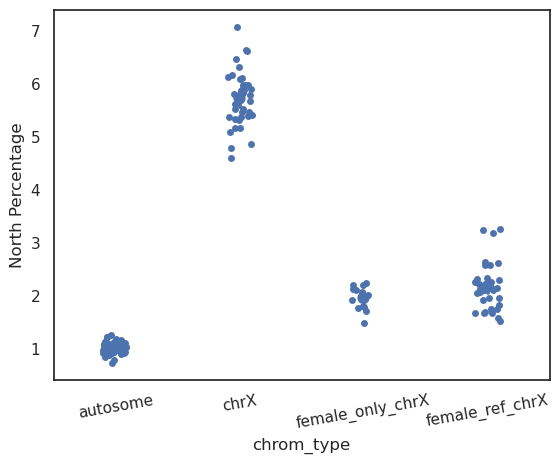

In [10]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Mikumi, Tanzania"].PGDP_ID
window_picked = window_df_tanz.loc[window_df_tanz.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

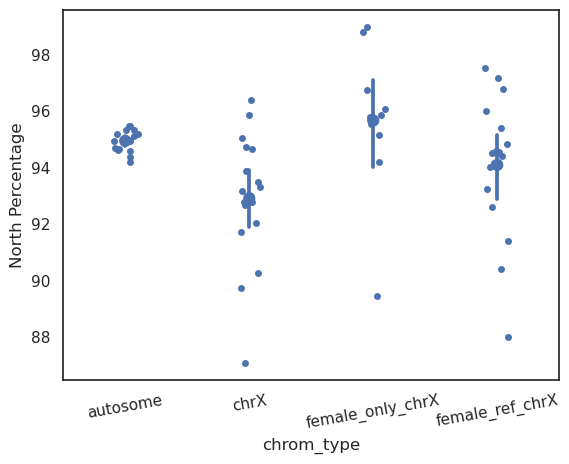

In [11]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Gombe, Tanzania"].PGDP_ID
window_picked = window_df_tanz.loc[window_df_tanz.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

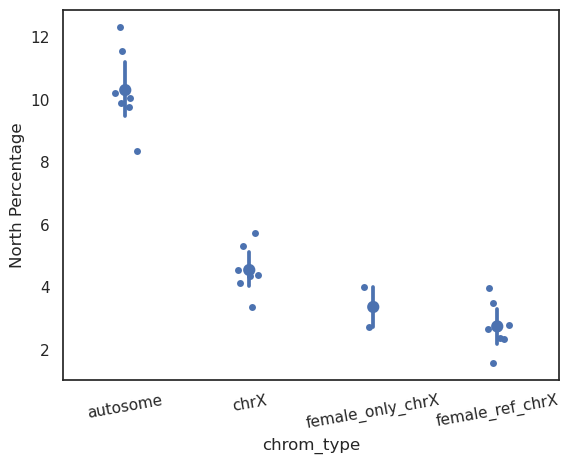

In [62]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Mahale, Tanzania"].PGDP_ID
window_picked = window_df_tanz.loc[window_df_tanz.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

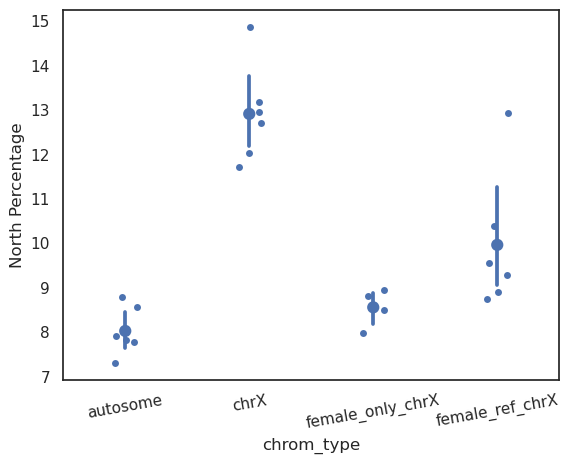

In [12]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Ruaha, Tanzania"].PGDP_ID
window_picked = window_df_tanz.loc[window_df_tanz.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

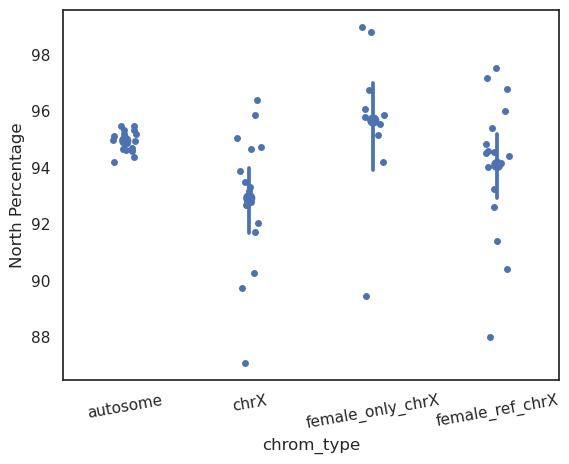

In [13]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Gombe, Tanzania"].PGDP_ID
window_picked = window_df_tanz.loc[window_df_tanz.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

In [14]:
rfmix_path = "../steps/rfmix_gen100/tanzania_close_focus/"

df_l = []
chroms = ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]
for c in chroms:
    read_file = rfmix_path + "{}.windows.txt".format(c)
    df = pd.read_csv(read_file, sep="\t")
    df_l.append(df)
window_df_tanz_close = pd.concat(df_l)
mean_window_df_tanz_close = window_df_tanz_close.groupby(["chrom", "individual", "start", "end"]).mean().reset_index()

In [15]:
meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Selous, Tanzania"].PGDP_ID

46    PD_0235
47    PD_0236
48    PD_0237
Name: PGDP_ID, dtype: object

In [16]:
window_df_tanz_close.loc[window_df_tanz_close.individual == "PD_0238"]

,chrom,individual,haplotype,start,end,north_sum
152250,chr1,PD_0238,0,0,100000,99840
152251,chr1,PD_0238,0,100000,200000,100000
152252,chr1,PD_0238,0,200000,300000,100000
152253,chr1,PD_0238,0,300000,400000,100000
152254,chr1,PD_0238,0,400000,500000,100000
...,...,...,...,...,...,...
100585,female_ref_chrX,PD_0238,1,143200000,143300000,100000
100586,female_ref_chrX,PD_0238,1,143300000,143400000,100000
100587,female_ref_chrX,PD_0238,1,143400000,143500000,100000
100588,female_ref_chrX,PD_0238,1,143500000,143600000,100000


(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

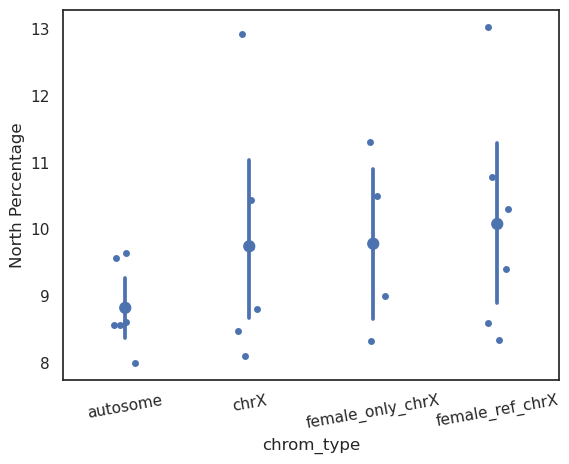

In [17]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Ruaha, Tanzania"].PGDP_ID
window_picked = window_df_tanz_close.loc[window_df_tanz_close.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

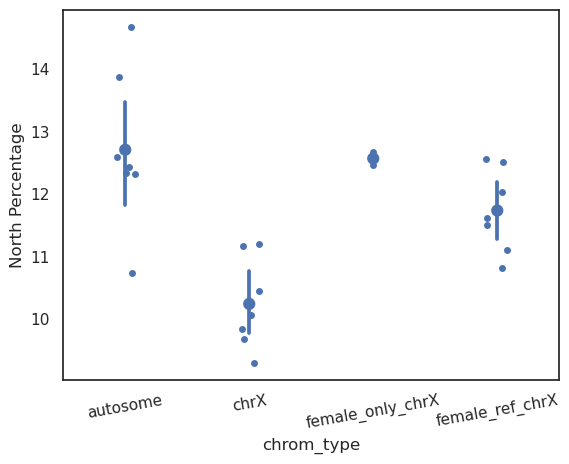

In [63]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Mahale, Tanzania"].PGDP_ID
window_picked = window_df_tanz_close.loc[window_df_tanz_close.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

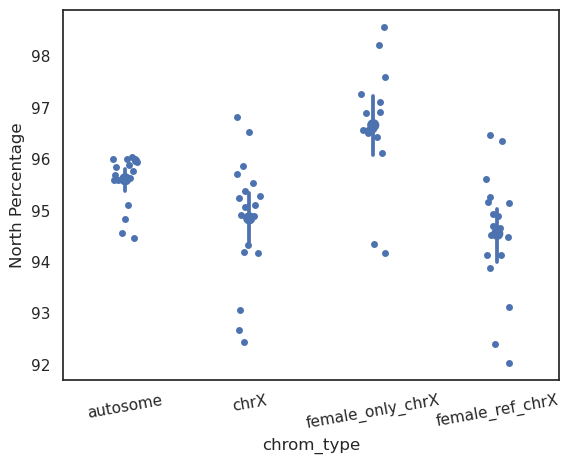

In [18]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Lake Manyara, Tanzania"].PGDP_ID
window_picked = window_df_tanz_close.loc[window_df_tanz_close.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

In [19]:
from scipy import stats
# Distant references
window_df_chrX = window_df_tanz.loc[window_df_tanz["chrom"].isin(["all_chrX"])].groupby(["chrom", "individual", "start", "end"])[["north_sum"]].mean().reset_index()
window_df_chrX["chrom"] = "chrX"
window_df_chrX = window_df_chrX.merge(c_r_g_df, on=["chrom", "start", "end"])
window_df_aut = window_df_tanz.loc[~window_df_tanz["chrom"].isin(["all_chrX", "female_chrX", "female_ref_chrX"])].groupby(["chrom", "individual", "start", "end"])[["north_sum"]].mean().reset_index().merge(c_r_g_df, on=["chrom", "start"])
# Close references
window_df_chrX_close = window_df_tanz_close.loc[window_df_tanz_close["chrom"].isin(["all_chrX"])].groupby(["chrom", "individual", "start", "end"])[["north_sum"]].mean().reset_index()
window_df_chrX_close["chrom"] = "chrX"
window_df_chrX_close = window_df_chrX_close.merge(c_r_g_df, on=["chrom", "start", "end"])
window_df_aut_close = window_df_tanz_close.loc[~window_df_tanz_close["chrom"].isin(["all_chrX", "female_chrX", "female_ref_chrX"])].groupby(["chrom", "individual", "start", "end"])[["north_sum"]].mean().reset_index().merge(c_r_g_df, on=["chrom", "start"])

In [20]:
o_l, i_l, admixture_l, admixture_close_l, admixture_chrX_l, admixture_close_chrX_l = [], [], [], [], [], []
aut_corr_l, chrX_corr_l = [], []
for o in ['Selous, Tanzania', 'Udzungwa, Tanzania', 'Ruaha, Tanzania',
       'Tarangire, Tanzania', 'Arusha, Tanzania', 'Ngorongoro, Tanzania', 'Gombe, Tanzania', 
             'Lake Manyara, Tanzania']:
    print(o)
    ids = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == o].PGDP_ID
    for i in ids:
        ind_window_all_chrX = window_df_chrX.loc[(window_df_chrX.individual == i) &
                                           (window_df_chrX.callable_frac > 0.75)]
        ind_window_all = window_df_aut.loc[(window_df_aut.individual == i)&
                                           (window_df_aut.callable_frac > 0.75)]
        ind_window_close_chrX = window_df_chrX_close.loc[(window_df_chrX_close.individual == i)&
                                           (window_df_chrX_close.callable_frac > 0.75)]
        ind_window_close = window_df_aut_close.loc[(window_df_aut_close.individual == i)&
                                           (window_df_aut_close.callable_frac > 0.75)]
        o_l.append(o), i_l.append(i)
        if o in ['Ruaha, Tanzania', 'Selous, Tanzania', 'Udzungwa, Tanzania']:
            admixture_l.append(ind_window_all.north_sum.mean()/1000)
            admixture_close_l.append(ind_window_close.north_sum.mean()/1000)
            admixture_chrX_l.append(ind_window_all_chrX.north_sum.mean()/1000)
            admixture_close_chrX_l.append(ind_window_close_chrX.north_sum.mean()/1000)
            aut_corr_l.append(stats.pearsonr(ind_window_all.north_sum, ind_window_close.north_sum)[0])
            chrX_corr_l.append(stats.pearsonr(ind_window_all_chrX.north_sum, ind_window_close_chrX.north_sum)[0])
        else:
            admixture_l.append(100-ind_window_all.north_sum.mean()/1000)
            admixture_close_l.append(100-ind_window_close.north_sum.mean()/1000)
            admixture_chrX_l.append(100-ind_window_all_chrX.north_sum.mean()/1000)
            admixture_close_chrX_l.append(100-ind_window_close_chrX.north_sum.mean()/1000)
            aut_corr_l.append(stats.pearsonr(ind_window_all.north_sum, ind_window_close.north_sum)[0])
            chrX_corr_l.append(stats.pearsonr(ind_window_all_chrX.north_sum, ind_window_close_chrX.north_sum)[0])

Selous, Tanzania


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


Udzungwa, Tanzania
Ruaha, Tanzania
Tarangire, Tanzania
Arusha, Tanzania
Ngorongoro, Tanzania
Gombe, Tanzania
Lake Manyara, Tanzania


In [21]:
correlation_df = pd.DataFrame({"Origin": o_l, "Distant autosomal MPA": admixture_l,
              "Close autosomal MPA": admixture_close_l, "Autosomal Correlation": aut_corr_l,
              "Distant ChrX MPA": admixture_chrX_l, "Close ChrX MPA": admixture_close_chrX_l,
              "ChrX Correlation": chrX_corr_l})

In [22]:
correlation_df.groupby(["Origin"]).mean().reset_index()

,Origin,Distant autosomal MPA,Close autosomal MPA,Autosomal Correlation,Distant ChrX MPA,Close ChrX MPA,ChrX Correlation
0,"Arusha, Tanzania",7.31,6.82,0.895,6.2,5.97,0.795
1,"Gombe, Tanzania",4.95,3.66,0.807,6.31,4.84,0.86
2,"Lake Manyara, Tanzania",4.99,4.35,0.803,5.05,4.44,0.76
3,"Ngorongoro, Tanzania",5.16,4.31,0.81,4.2,4.01,0.694
4,"Ruaha, Tanzania",8.02,8.83,0.889,12.9,9.69,0.698
5,"Selous, Tanzania",0.316,0.214,0.602,4.52,0.0389,0.108
6,"Tarangire, Tanzania",20.9,20.6,0.946,25,25.8,0.915
7,"Udzungwa, Tanzania",1.34,1.29,0.797,6.14,1.71,0.434


The consistent problem that reviewer 1 points out is that there is too much admixture on chrX compared to their RFmix results.
I was also surprised by this, but had faith in the RFmix results. Now I want to check whether different settings will change the chrX observations.

In [31]:
rfmix_path = "../steps/rfmix_gen100/tanzania_focus_plain/"

df_l = []
chroms = ["chr{}".format(x) for x in (range(4, 7))]+["all_chrX", "female_chrX", "female_ref_chrX"]
for c in chroms:
    read_file = rfmix_path + "{}.windows.txt".format(c)
    df = pd.read_csv(read_file, sep="\t")
    df_l.append(df)
window_df_tanz_plain = pd.concat(df_l)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

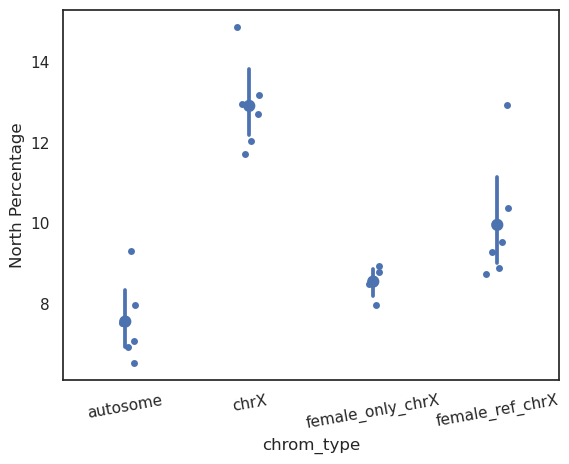

In [36]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Ruaha, Tanzania"].PGDP_ID
window_picked = window_df_tanz_plain.loc[window_df_tanz_plain.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

In [40]:
rfmix_path = "../steps/rfmix_gen100/tanzania_close_focus_plain/"

df_l = []
chroms = ["chr{}".format(x) for x in (range(4, 7))]+["all_chrX", "female_chrX", "female_ref_chrX"]
for c in chroms:
    read_file = rfmix_path + "{}.windows.txt".format(c)
    df = pd.read_csv(read_file, sep="\t")
    df_l.append(df)
window_df_tanz_close_plain = pd.concat(df_l)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

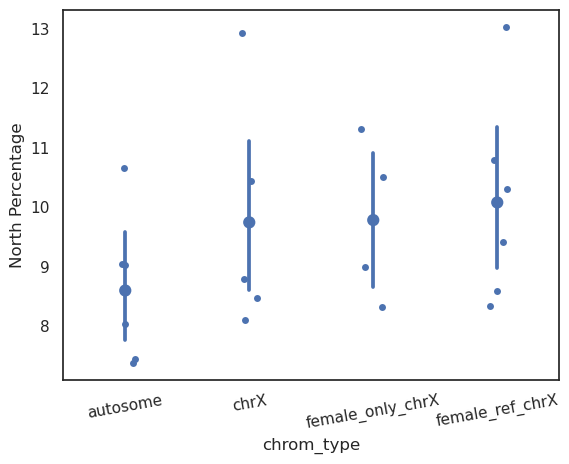

In [41]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Ruaha, Tanzania"].PGDP_ID
window_picked = window_df_tanz_close_plain.loc[window_df_tanz_close_plain.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

Finally, checking eth focus.

In [54]:
rfmix_path = "../steps/rfmix_gen100/eth_olive_focus/"

df_l = []
chroms = ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]
for c in chroms:
    read_file = rfmix_path + "{}.windows.txt".format(c)
    df = pd.read_csv(read_file, sep="\t")
    df_l.append(df)
window_df_eth_olive = pd.concat(df_l)

In [55]:
window_df_eth_olive

,chrom,individual,haplotype,start,end,north_sum
0,chr1,PD_0228,0,0,100000,0
1,chr1,PD_0228,0,100000,200000,0
2,chr1,PD_0228,0,200000,300000,0
3,chr1,PD_0228,0,300000,400000,0
4,chr1,PD_0228,0,400000,500000,0
...,...,...,...,...,...,...
192553,female_ref_chrX,Sci_34474,1,143200000,143300000,0
192554,female_ref_chrX,Sci_34474,1,143300000,143400000,0
192555,female_ref_chrX,Sci_34474,1,143400000,143500000,0
192556,female_ref_chrX,Sci_34474,1,143500000,143600000,0


(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

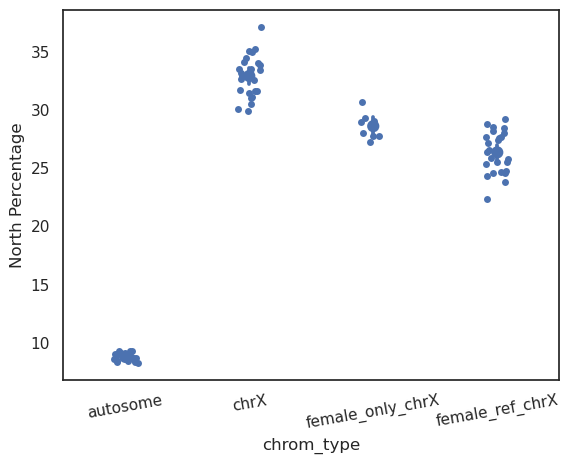

In [58]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == 'Gog Woreda, Gambella region, Ethiopia'].PGDP_ID
window_picked = window_df_eth_olive.loc[window_df_eth_olive.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)